# Quadcopter Cascade PID — Figure-8 Trajectory Tracking

This notebook presents a three-loop cascade PID simulation of a quadcopter tracking a figure-8 ($\infty$) trajectory. It models the quadcopter dynamics, builds the control hierarchy, and runs the simulation using [c4dynamics](https://c4dynamics.github.io/c4dynamics/).

---

## Goal

Understand the following example and adjust it to simulate your drone parameters tracking figure-8.

---



## Notebook Overview

1. Quadcopter initialization  
2. Figure-8 dimensions setting  
3. Cascade PID overview and architecture
4. Simulation
5. Results

- At the end of every section, a code snippet is configuring the simulating objects.
- After running the example, change the quadcopter and the figure-8 configurations to support your own system.


**To keep the notebook focused on tuning and results, the implementation details are collected in a supporting utility file, `quad_pid_utils.py`.**



---

## 1. Setup

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install c4dynamics

from quad_pid_utils import (run_fig8_pid,
                             plot_results,
                             compute_metrics
                             )

---
## 2. Quadcopter


### State Variables

The quadcopter is a 12-state rigid body object with position, velocity, Euler angles, and body angular rates:

$$\mathbf{X} = [x,\ y,\ z,\ v_x,\ v_y,\ v_z,\ \varphi,\ \theta,\ \psi,\ p,\ q,\ r]^T$$

Where:
- $x, y, z$: position of the quadcopter in the inertial frame [m]
- $v_x, v_y, v_z$: linear velocity components in the inertial frame [m/s]
- $\varphi$ (phi): roll angle — rotation about the body X-axis [rad]
- $\theta$ (theta): pitch angle — rotation about the body Y-axis [rad]
- $\psi$ (psi): yaw angle — rotation about the body Z-axis [rad]
- $p, q, r$: angular rate components about the body X, Y, Z axes respectively [rad/s]

The four control inputs are:

$$\mathbf{U} = [F,\ \tau_\varphi,\ \tau_\theta,\ \tau_\psi]^T$$

Where:
- $F$: total thrust force produced by all four rotors combined [N]
- $\tau_\varphi$: roll torque — differential thrust between left and right motors [N·m]
- $\tau_\theta$: pitch torque — differential thrust between front and rear motors [N·m]
- $\tau_\psi$: yaw torque — differential drag torque from counter-rotating motor pairs [N·m]


The quadcopter starts on the ground stationary level. A `quad` [object](https://c4dynamics.github.io/c4dynamics/api/states.lib.rigidbody.html) initializes the state, stores every sample during the simulation, and provides history retrieval for plotting and metrics via `quad.data()`.



## Reference Frame 

In this work we adopt the FRD (front-right-down) for the body referece frame and ENU (east-north-up) for the inertial frame (see figure 1).  
In this body frame convention, the thurst acts along the negative body z-axis ($-z_b$).  
Positive rates about an axis is given by curling the right-hand fingers.  
Propellers rotation:   
Rotor 1: CCW (counter=clockwise)  
Rotor 2: CCW  
Rotor 3: CW  
Rotor 4: CW  
Yaw torque arises from the reaction torques of the rotors, with clockwise propeller causes a counter-clockwise moment on the quadcopter.


<div style="text-align: center;">
  <img src="quad_frame.png" alt="alt text">
  <figcaption> Figure 1: Reference systems. Inertial system: ENU (east, north, up). Body frame: (forward, right, down). Positive rotation about an axis is given by curling the right-hand fingers. Propellers rotation: 1: CCW (counter=clockwise) , 2: CCW, 3: CW, 4: CW. 
   </figcaption>
</div>


### Dynamics

The quadcopter is modeled by the full nonlinear Newton-Euler equations.

**Translational dynamics** (inertial frame):

$$m \ddot{\mathbf{r}} = \mathbf{F}_{thrust} + \mathbf{F}_{drag} + \mathbf{F}_{gravity}$$

Where:
- $m$: total mass of the quadcopter [kg]
- $\ddot{\mathbf{r}}$: linear acceleration vector in the inertial frame [m/s²]
- $\mathbf{F}_{thrust}$: total rotor thrust force, projected from body frame to inertial frame [N]
- $\mathbf{F}_{drag}$: aerodynamic drag force, proportional to velocity [N]
- $\mathbf{F}_{gravity}$: gravitational force acting downward on the quadcopter [N]


The thrust $F$ acts along $-Z_b$ and is projected to the inertial frame via the ZYX rotation matrix.

**Rotational dynamics** (Euler's equations in body frame):

$$\mathbf{I}\dot{\boldsymbol{\omega}} + \boldsymbol{\omega} \times \mathbf{I}\boldsymbol{\omega} = \boldsymbol{\tau}$$

Where:
- $\mathbf{I}$: inertia tensor of the quadcopter body, diagonal with entries $I_{xx}, I_{yy}, I_{zz}$ [kg·m²]
- $\dot{\boldsymbol{\omega}}$: angular acceleration vector in the body frame [rad/s²]
- $\boldsymbol{\omega} = [p, q, r]^T$: angular velocity vector in the body frame [rad/s]
- $\boldsymbol{\omega} \times \mathbf{I}\boldsymbol{\omega}$: gyroscopic (Coriolis) term arising from the rotating body frame — couples the three rotation axes
- $\boldsymbol{\tau} = [\tau_\varphi,\ \tau_\theta,\ \tau_\psi]^T$: torque vector produced by differential rotor thrust [N·m]. A gyroscopic coupling term from rotor angular momentum is also included.

The `dynamics(t, y, quad, rotor_speeds)` function computes the 12 state derivatives.  
Integration is carried out by using scipy's `solve_ivp`.

For the full theoretical background on rigid-body kinematics and the state representation used by c4dynamics, see the [c4dynamics kinematics page](https://c4dynamics.github.io/c4dynamics/concepts/kinematics.html).


### Config

In [2]:
quadcopter = {
    'm'  : 0.468,      # mass [kg]
    'g'  : 9.81,       # gravity [m/s^2]
    'l'  : 0.225,      # arm length — center to motor [m]
    'kT' : 2.98e-6,    # thrust coefficient  [N/(rad/s)^2]
    'kQ' : 0.0382,     # torque coefficient  [N.m/(rad/s)^2]
    'Ixx': 4.856e-3,   # roll  inertia [kg.m^2]
    'Iyy': 4.856e-3,   # pitch inertia [kg.m^2]
    'Izz': 8.801e-3,   # yaw   inertia [kg.m^2]
    'Ax' : 0.30,       # aero drag — x
    'Ay' : 0.30,       # aero drag — y
    'Az' : 0.25,       # aero drag — z
    'Ar' : 0.20,       # rotational drag — angular rates
    'IR' : 3.357e-5,   # rotor inertia [kg.m^2]
}



---
## 3. Trajectory

The reference to the flight is a **Lissajous figure-8** in the horizontal plane at a fixed altitude:

$$
x_{ref}(t) = A \cdot \sin(\omega \cdot \tau) \\
y_{ref}(t) = B \cdot \sin(2\omega \cdot \tau) \\
z_{ref}(t) = z_{ref}
$$

Where:
- $x_{ref}, y_{ref}, z_{ref}$: desired position the quadcopter must track [m]
- $A$: trajectory amplitude in the X direction [m]
- $B$: trajectory amplitude in the Y direction [m]
- $\omega$: angular frequency of the trajectory [rad/s]; period $= 2\pi/\omega$
- $\tau = t - t_{takeoff}$: time elapsed since the figure-8 phase started [s]
- $t_{takeoff}$: time at which the figure-8 phase begins [s]

This is a standard benchmark for trajectory tracking controllers because it combines simultaneous motion in both horizontal axes, continuous direction reversals, and a non-trivial curvature profile — all of which stress-test the controller's ability to reject coupling errors and follow a dynamic reference.


<div style="text-align: center;">
  <img src="Fig_8_Marked.png" alt="alt text">
  <figcaption>Figure 2: top view of a figure-8 trajectory with marks of the $A$ and $B$ dimensions.
   </figcaption>
</div>


### Physical Meanings

| Parameter | meaning |
|-----------|------------------|
| `A` | Half-width of the figure-8 in the X direction [m]. Larger values mean a wider trajectory. |
| `B` | Half-width in the Y direction [m]. Controls the "height" of each lobe of the figure-8. |
| `omega` | Angular frequency [rad/s]. Controls how fast the quadcopter flies the path. Period = $2\pi/\omega$. |
| `z_ref` | Constant hover altitude [m]. The quadcopter holds this height throughout the maneuver. |


### 3-Phase Flight

| Phase | Duration | Description |
|-------|----------|-------------|
| **Takeoff** | 0 — 8s | Z rises from 0 to `z_ref` on a smooth S-curve |
| **Figure-8** | 8s — (end-8s) | X/Y track the Lissajous at constant altitude |
| **Landing** | last 8s | X/Y return to origin, Z descends to 0 |


- In the utility file `quad_pid_utils.py`, the functions `position_reference(t, ...)` and `velocity_reference(t, ...)` return the instantaneous reference position and velocity at any time `t`.


### Config

In [3]:
trajectory = {
    'A'    : 4.0,    # figure-8 X amplitude [m]
    'B'    : 2.0,    # figure-8 Y amplitude [m]
    'omega': 0.1,    # angular frequency [rad/s]  (period ~ 62.8 s)
    'z_ref': 1.5,    # hover altitude [m]
    't_end': 90.0,   # total simulation time [s]
}

---
## 4. Cascade PID Control

### Why Cascade PID?

A quadcopter is **underactuated** — 6 degrees of freedom, only 4 control inputs. To move horizontally the quadcopter must tilt, which means position and attitude are tightly coupled. A single PID loop cannot handle this. The cascade structure separates the problem by bandwidth:

| Loop | Rate | Input | Output |
|------|------|-------|--------|
| **Outer** — Position | 50 Hz | Position error $(x, y, z)$ | Desired angles $\varphi_d, \theta_d$ + thrust $F$ |
| **Middle** — Attitude | 100 Hz | Angle error $(\varphi, \theta, \psi)$ | Desired body rates $(p_d, q_d, r_d)$ |
| **Inner** — Rate | 200 Hz | Rate error $(p, q, r)$ | Torques $(\tau_\varphi, \tau_\theta, \tau_\psi)$ |

**Tuning order:** always tune inner first, then middle, then outer. Each loop must be stable before the next loop is closed around it.


<div style="text-align: center;">
  <img src="Cascade_PID.png" alt="alt text">
  <figcaption>Figure 3: cascade PID with 3 loops - to control position (outer), attitude (middle), and rates (inner).
   </figcaption>
</div>



### Control Law

Each controller implements:

$$u = K_p \cdot e + K_i \cdot \int e\, dt - K_d \cdot \dot{m}$$

Where:
- $u$: control output — setpoint to the next inner loop, or actuator command for the innermost loop
- $K_p, K_i, K_d$: proportional, integral, and derivative gains
- $e$: error — difference between the desired setpoint and the current measured value
- $\int e\, dt$: accumulated error over time
- $\dot{m}$: time derivative of the measurement (not the error), to avoid derivative kick on setpoint changes

The derivative acts on the **measurement** $\dot{m}$, not on the error — this eliminates derivative kick when the setpoint changes. All integrators include anti-windup clamping. The outer loop adds a **velocity feedforward** term to reduce phase lag on curved trajectories.

### Control Allocation

The motor layout is (x) configuration.

The four control inputs $[F, \tau_\varphi, \tau_\theta, \tau_\psi]$ are mapped to individual rotor speeds by inverting the thrust-torque mixing matrix:

$$\begin{bmatrix} \Omega_1^2 \\ \Omega_2^2 \\ \Omega_3^2 \\ \Omega_4^2 \end{bmatrix} = \mathbf{\Gamma}^{-1} \begin{bmatrix} F \\ \tau_\varphi \\ \tau_\theta \\ \tau_\psi \end{bmatrix}$$

Where:
- $\Omega_1, \Omega_2, \Omega_3, \Omega_4$: individual rotor angular speeds [rad/s]
- $\mathbf{\Gamma}^{-1}$: inverse of the thrust-torque mixing matrix — maps desired thrust and torques to individual rotor speeds
- $F$: total desired thrust [N]
- $\tau_\varphi, \tau_\theta, \tau_\psi$: desired roll, pitch, and yaw torques [N·m]

The normalized (geometric factors are handled separately) mixer matrix $\mathbf{\Gamma}^{-1}$ for an x configuration with prepellents 1, 2 CCW and 3, 4 CW is given by: 

$$
\begin{bmatrix} 
1 & -1 &  \ \ \ 1 & \ \ \  1 \\ 
1 & \ \ \ 1 & -1 &  \ \ \ 1 \\ 
1 & \ \ \ 1 & \ \ \ 1 & -1 \\ 
1 & -1 & -1 & -1 
\end{bmatrix}
$$

This matrix is the inverse of the force–torque mapping derived from rotor positions and spin directions.  
Each row corresponds to one motor, and each column represents the contribution of thrust, roll, pitch, and yaw.

The method `allocate` of `ControlAllocator` clamps $\Omega_i^2 \geq 0$ (rotors cannot pull) and $\Omega_i \leq \Omega_{max}$ before taking the square root.

### Config

In [4]:
controller = {

    # Inner loop — angular rate (200 Hz)
    'Kp_p': 0.80,  'Ki_p': 0.0001,  'Kd_p': 0.010,
    'Kp_q': 0.80,  'Ki_q': 0.0001,  'Kd_q': 0.010,
    'Kp_r': 0.60,  'Ki_r': 0.0001,  'Kd_r': 0.008,

    # Middle loop — attitude (100 Hz)
    'Kp_phi'  : 6.0,  'Ki_phi'  : 0.0001,  'Kd_phi'  : 0.80,  'AW_phi'  : 0.5,
    'Kp_theta': 6.0,  'Ki_theta': 0.0001,  'Kd_theta': 0.80,  'AW_theta': 0.5,
    'Kp_psi'  : 4.0,  'Ki_psi'  : 0.5,     'Kd_psi'  : 0.40,  'AW_psi'  : 0.5,

    # Outer loop — position (50 Hz)
    'Kp_x': 0.80,  'Ki_x': 0.00,  'Kd_x': 0.50,  'AW_x': 0.5,
    'Kp_y': 1.00,  'Ki_y': 0.00,  'Kd_y': 0.70,  'AW_y': 0.5,
    'Kp_z': 10.0,  'Ki_z': 10.0,  'Kd_z': 1.50,  'AW_z': 3.0,

    # Velocity feedforward
    'Kff_x': 0.35,  'Kff_y': 0.40,

    # Limits
    'N_rate'        : 50,       # Filter coefficient for derivative term in rate controller
    'omega_max'     : 1000.0,   # max rotor speed [rad/s]
    'T_max_factor'  : 4,        # max thrust factor: T_max = T_max_factor * K_thrust * omega_max**2	[N]
    'T_min'         : 0.0,      # min thrust [N]
    'att_cmd_limit' : 0.314,    # Max attitude command [rad] = 18deg
    'yaw_rate_limit': 1.0,      # Max yaw rate command [rad/s]
}



---
## 5. Simulation

The simulation loop advances the quadcopter state from `t = 0` to `t = tf`.

At each timestep the three cascade loops fire at their respective rates:
- the outer position loop every 4 steps (50 Hz)
- the middle attitude loop every 2 steps (100 Hz)
- the inner rate loop every step (200 Hz).

`quad.store(t)` logs the full state vector.  
`quad.storeparams(...)` logs the control inputs.  
After the loop, all histories are available via `quad.data()`.  


### Config

In [5]:
simulation = {
    'dt': 5e-3,    # master timestep [s] = inner loop (200 Hz)
    'tf': 90.0,    # simulation end time [s]
}

### Main Loop

In [6]:
# plug all the config files for the simulation entry:
config = {
    'quad': quadcopter,
    'controller': controller,
    'trajectory': trajectory,
    'sim': simulation
}

### Run Simulation

In [7]:
quad = run_fig8_pid(config)

Simulation start  |  tf = 90.0 s  |  dt = 0.005 s
Simulation run  |  t = 0.0 s
Simulation run  |  t = 10.0 s
Simulation run  |  t = 20.0 s
Simulation run  |  t = 30.0 s
Simulation run  |  t = 40.0 s
Simulation run  |  t = 50.0 s
Simulation run  |  t = 60.0 s
Simulation run  |  t = 70.0 s
Simulation run  |  t = 80.0 s
Simulation complete.


---
## 8. Results

### What to Expect

A well-tuned cascade PID on this trajectory should show:

- **Position** — X and Y closely follow the sinusoidal references. Small amplitude and phase lag are normal.
- **Altitude** — Z rises sharply during takeoff, holds `z_ref` with very small deviation, and descends smoothly.
- **Euler angles** — roll and pitch stay within ±15°. Yaw remains near zero.
- **3D trajectory** — a clean takeoff lobe, the figure-8 loops, and a straight descent to origin.

All plots are generated from `quad.data()` — the stored histories in the `rigidbody` object.

### Trajectories and Angles

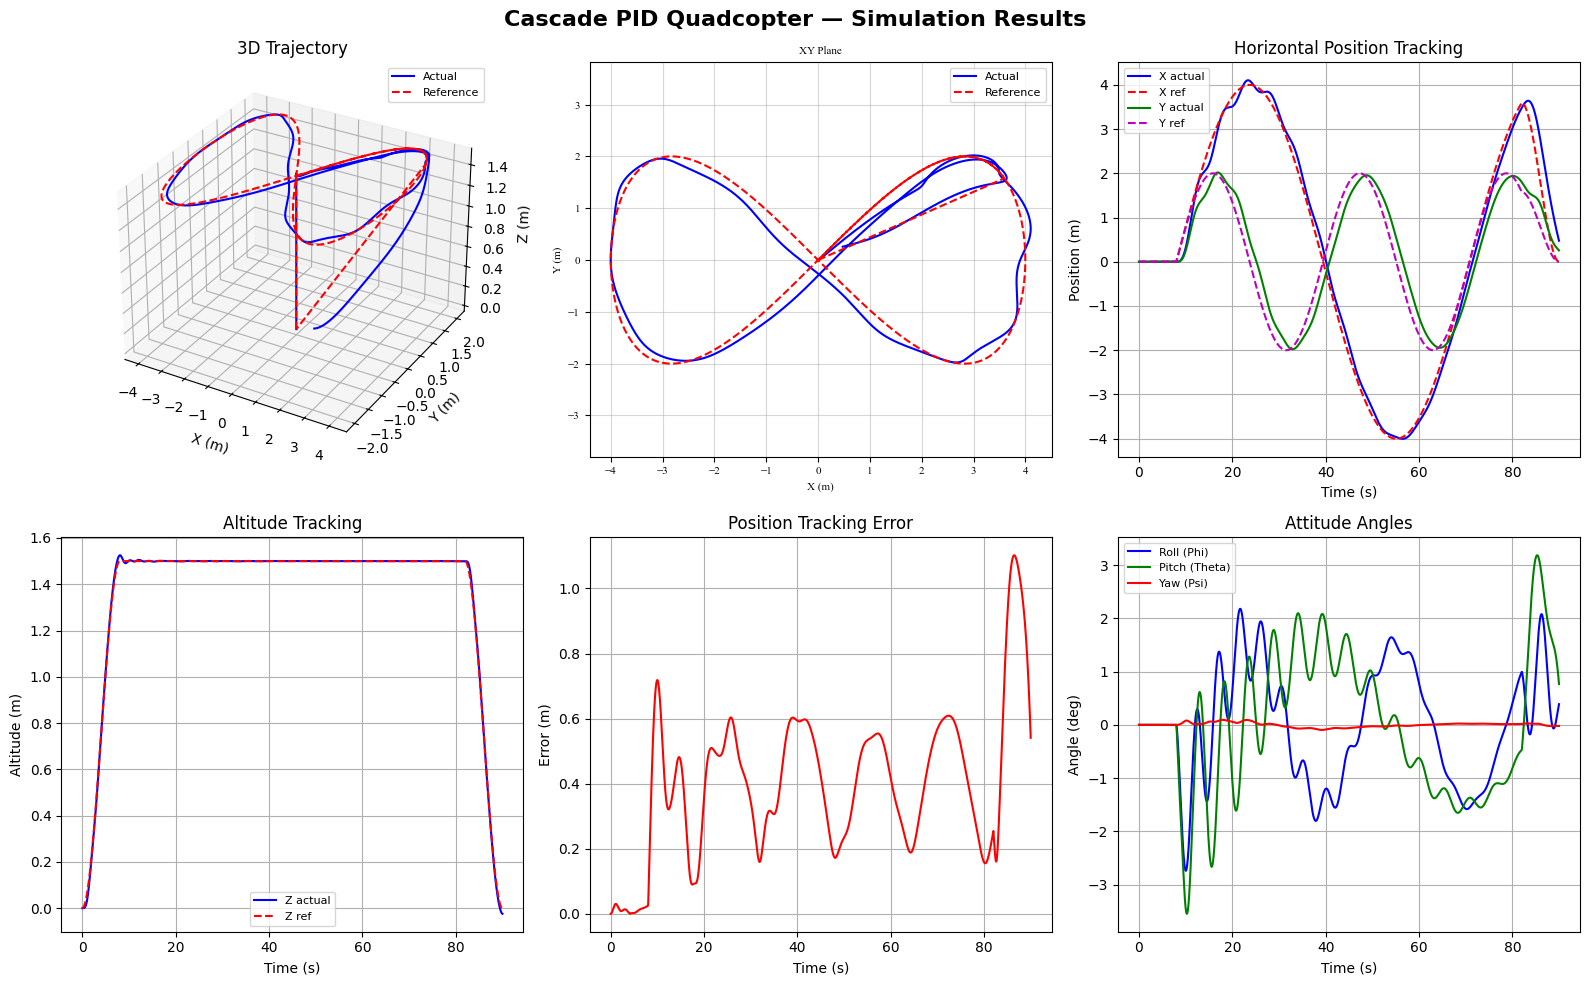

In [8]:
plot_results(quad, config['trajectory'])

### Tracking Metrics

`compute_metrics()` computes RMSE for X, Y, Z tracking over the **figure-8 phase only. Normalized RMSE expresses tracking error as a percentage of trajectory amplitude.

| Normalized RMSE | Interpretation |
|-----------------|----------------|
| < 5% | Excellent |
| 5 – 15% | Acceptable |
| > 15% | Retune from inner loop, or reduce `omega` |

In [9]:
metrics = compute_metrics(quad, trajectory)

print('=' * 45)
print('   TRACKING PERFORMANCE METRICS')
print('=' * 45)
print(f'  RMSE x : {metrics["rmse_x"]:.4f} m  ({metrics["norm_x"]:.1f}% of X amplitude)')
print(f'  RMSE y : {metrics["rmse_y"]:.4f} m  ({metrics["norm_y"]:.1f}% of Y amplitude)')
print(f'  RMSE z : {metrics["rmse_z"]:.6f} m  ({metrics["norm_z"]:.3f}% of altitude)')
print(f'  Max altitude deviation : {metrics["max_z_dev"]*100:.2f} cm')
print('=' * 45)



   TRACKING PERFORMANCE METRICS
  RMSE x : 0.1992 m  (5.0% of X amplitude)
  RMSE y : 0.3831 m  (19.2% of Y amplitude)
  RMSE z : 0.002137 m  (0.142% of altitude)
  Max altitude deviation : 2.53 cm
